# import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# EDA

In [3]:
df=pd.read_csv("breast-canser.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Description of data

In [4]:
#diagnosis: نوع الورم (خبيث أو حميد). # m=malignant 5abes w b=benign salem 
#• Radius: المسافة من المركز لنقط على المحيط (نصف القطر).
#• Texture: تباين درجات الرمادي في الصورة.
#• Perimeter: محيط الورم.
#• Area: مساحة الورم.
#• Smoothness: مدى انتظام طول نصف القطر.
#• Compactness: (المحيط^2 / المساحة) - 1.0.
#• Concavity: شدة الأجزاء المقعرة في المحيط.
#• Concave points: عدد الأجزاء المقعرة.
#• Symmetry: التماثل.
#• Fractal dimension: تعقيد حدود الورم.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df.drop(["id","Unnamed: 32"],axis=1,inplace=True)

In [7]:
df.duplicated().sum() 

0

In [8]:
df["diagnosis"]=df["diagnosis"].map({"M":1,"B":0}) # M malignant 1 w B benign 0

<Axes: xlabel='diagnosis', ylabel='count'>

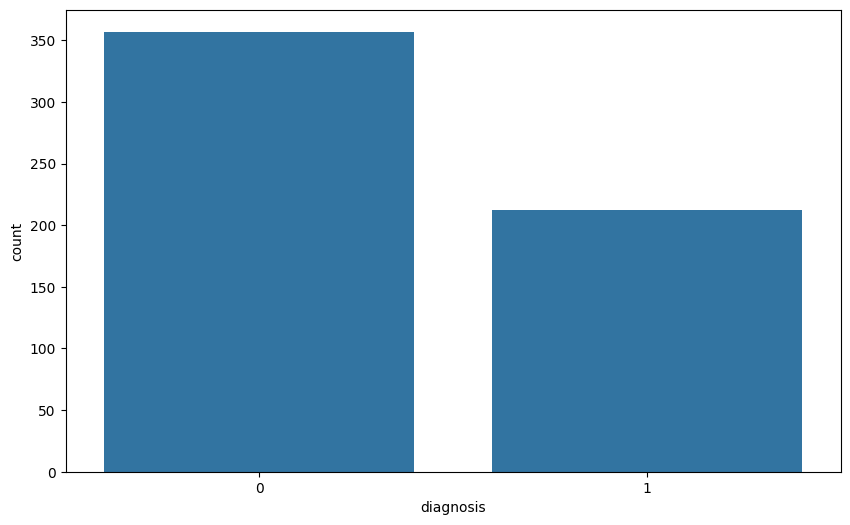

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(x="diagnosis",data=df)

<Axes: >

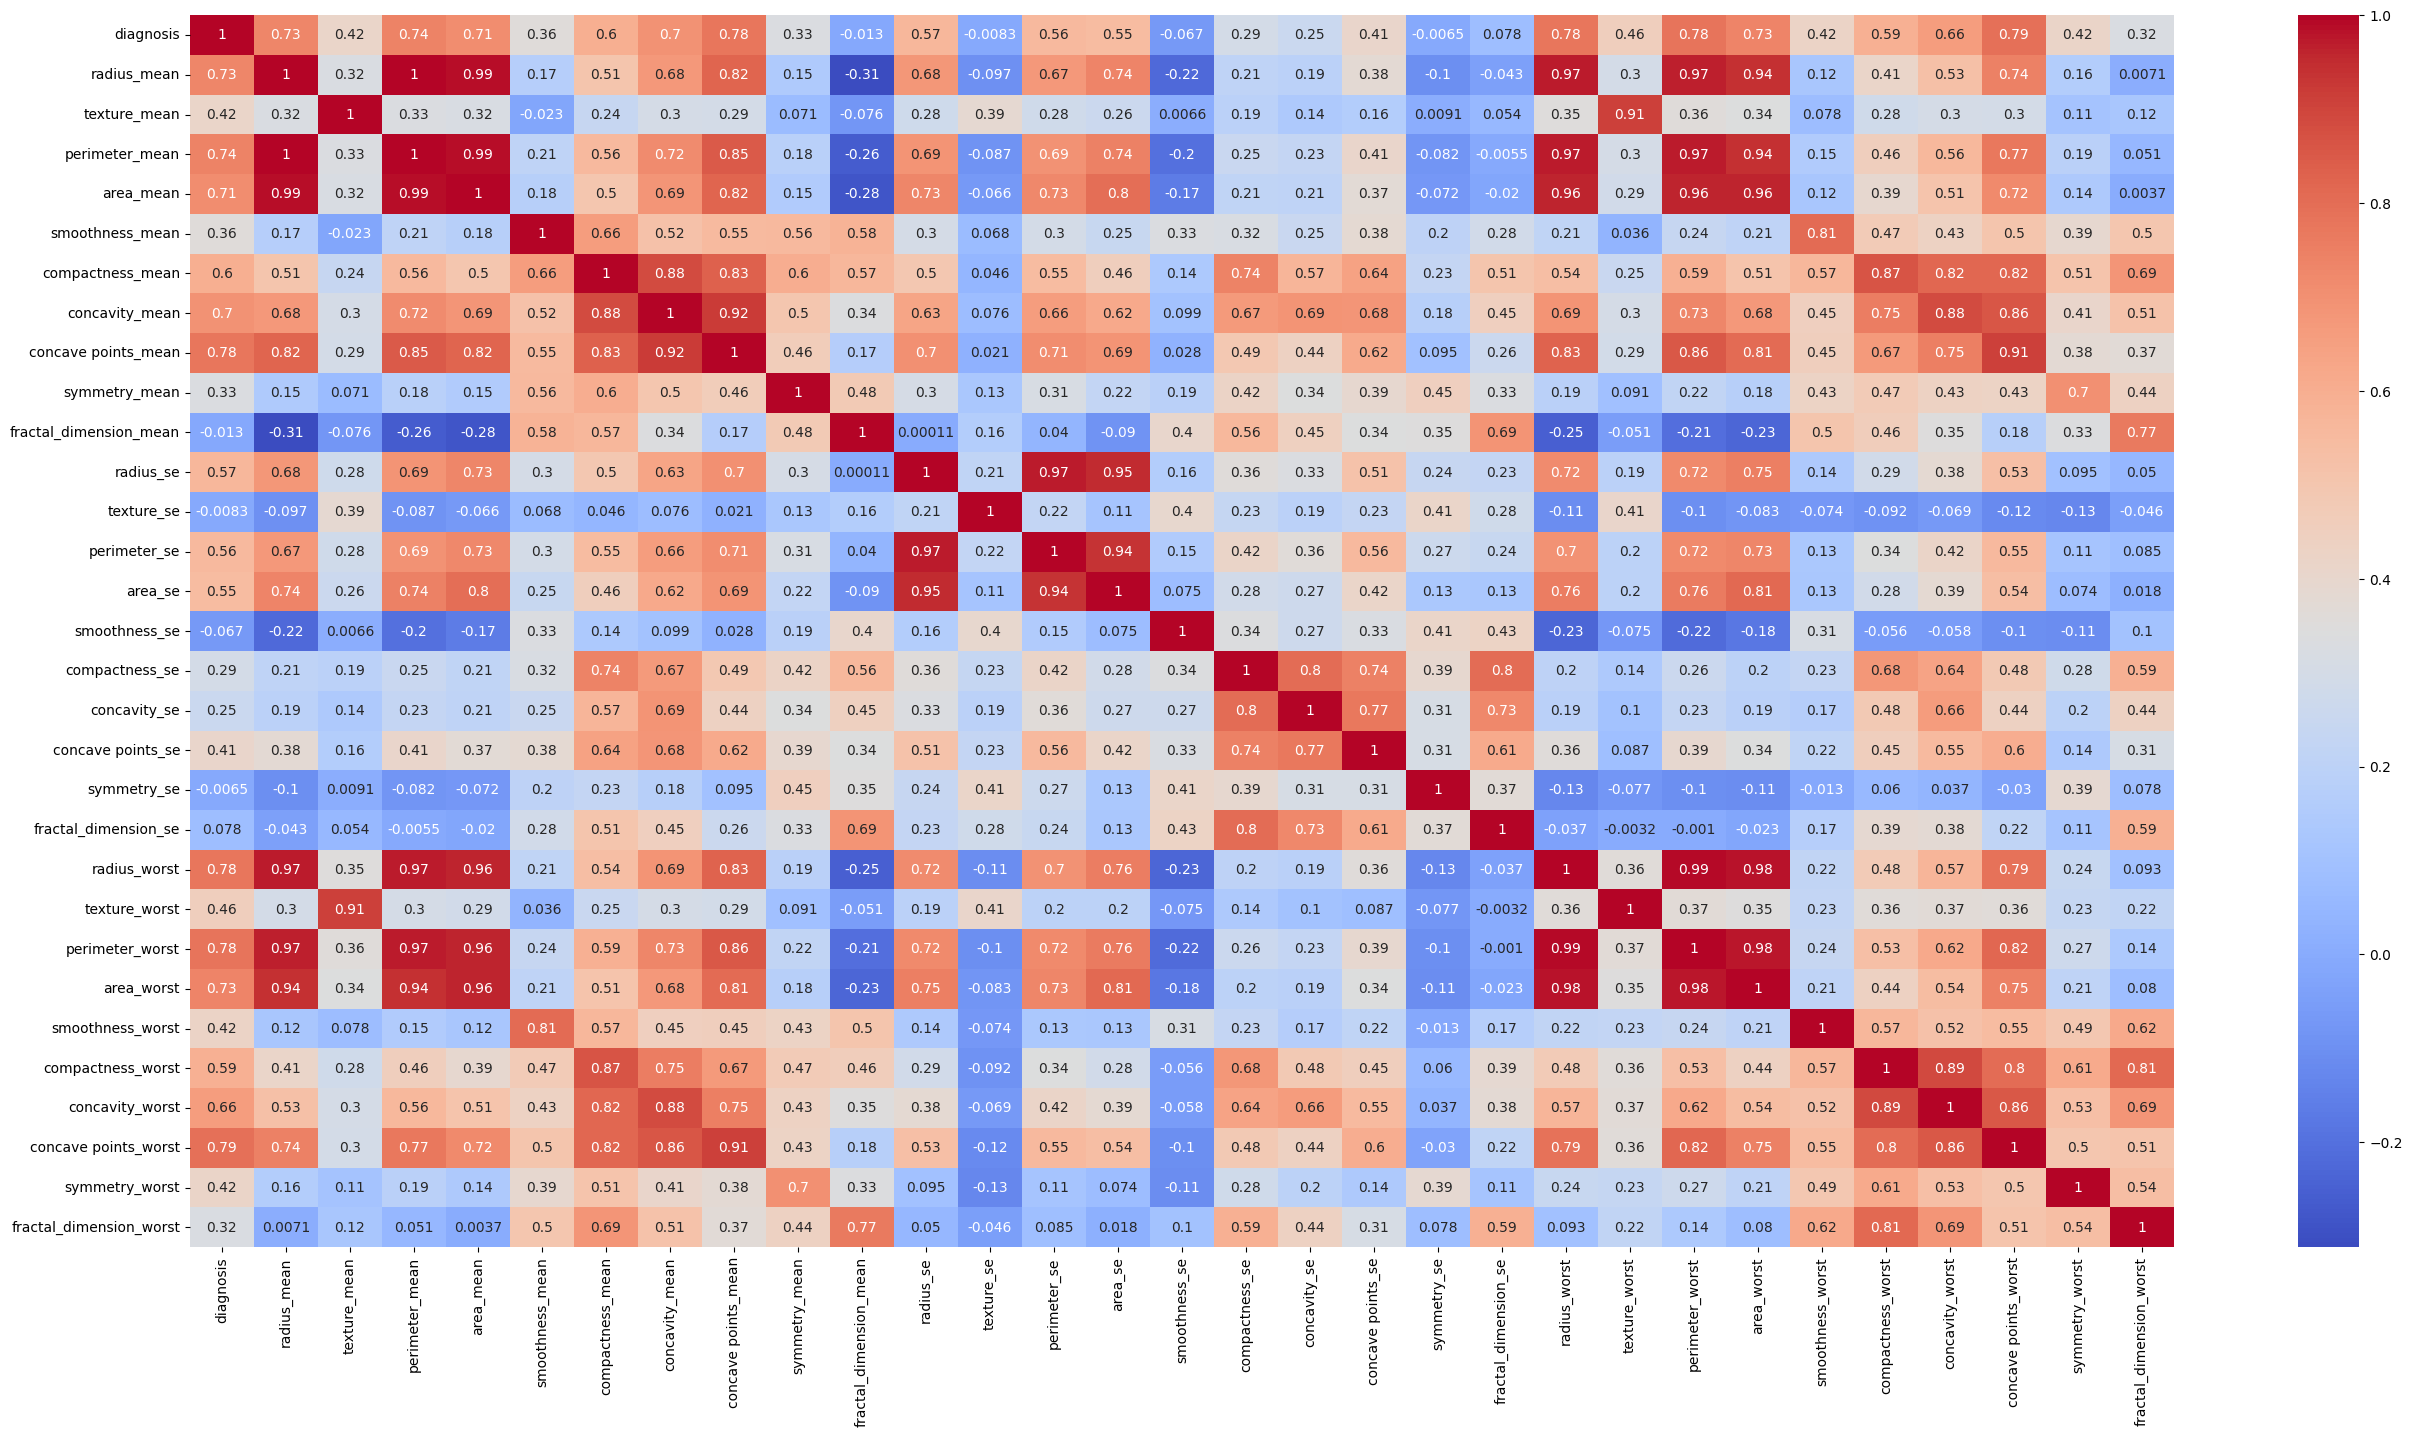

In [10]:
Correlation=df.corr()
plt.figure(figsize=(32,16))
sns.heatmap(Correlation,annot=True,cmap="coolwarm")

# Feature Selection

In [11]:
# 1. حذف الأعمدة الضعيفة (Low Variance)
weak_features = ['fractal_dimension_mean', 'texture_se', 'smoothness_se', 'symmetry_se', 'fractal_dimension_se']

# 2. حذف الأعمدة المكررة (Multicollinearity) 
redundant_features = ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'perimeter_worst', 'area_worst']

df.drop(weak_features + redundant_features, axis=1, inplace=True)

<Axes: xlabel='radius_mean', ylabel='Count'>

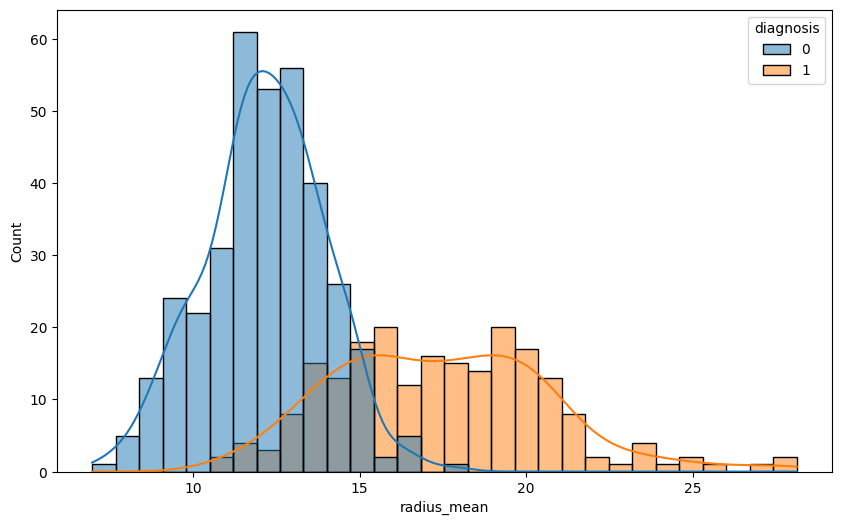

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(x="radius_mean",data=df,bins=30,hue="diagnosis",kde=True)

<Axes: xlabel='diagnosis', ylabel='radius_mean'>

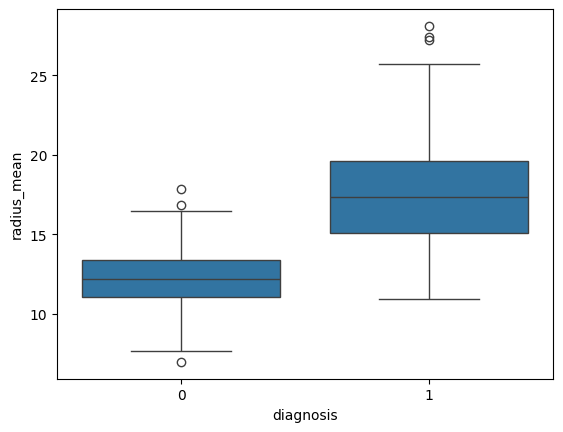

In [13]:
sns.boxplot(x="diagnosis",y="radius_mean",data=df)

# Preprocessing

In [14]:
x=df.drop("diagnosis",axis=1)
y=df["diagnosis"]

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
x_train= scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Model

In [17]:
model=Sequential()
model.add(Dense(16,activation="relu",input_shape=(x_train.shape[1],)))
model.add(Dense(8,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

C:\Users\MOHAMED ELSAYED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(optimizer=Adam(),loss="binary_crossentropy",metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.fit(x_train,y_train,epochs=100,batch_size=32,validation_split=0.2)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3269 - loss: 0.7584 - val_accuracy: 0.5275 - val_loss: 0.6979
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4698 - loss: 0.6895 - val_accuracy: 0.5934 - val_loss: 0.6441
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6016 - loss: 0.6437 - val_accuracy: 0.6813 - val_loss: 0.6036
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7610 - loss: 0.6042 - val_accuracy: 0.7253 - val_loss: 0.5643
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8242 - loss: 0.5660 - val_accuracy: 0.8132 - val_loss: 0.5250
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8571 - loss: 0.5262 - val_accuracy: 0.8242 - val_loss: 0.4832
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8791 - loss: 0.4839 - val_accuracy: 0.8462 - val_loss: 0.4402
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8901 - loss: 0.4418 - val_accuracy: 0.8681 - 

In [20]:
y_pred=model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [21]:
print(model.evaluate(x_train,y_train))
print(model.evaluate(x_test,y_test))


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9846 - loss: 0.0341 
[0.034075912088155746, 0.9846153855323792]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9649 - loss: 0.1069 
[0.10688599199056625, 0.9649122953414917]


<Axes: >

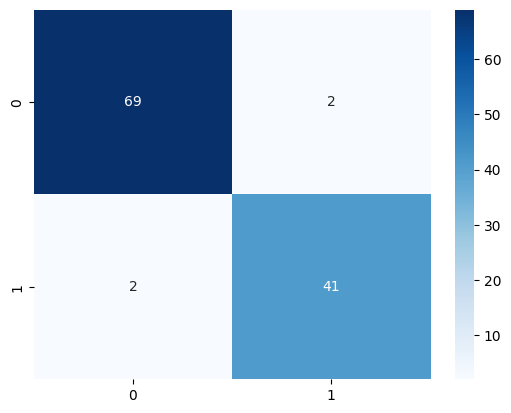

In [23]:
confusion_matrix=confusion_matrix(y_test,y_pred.round())
sns.heatmap(confusion_matrix,annot=True,cmap="Blues",fmt="g")

In [ ]:
classification_report(y_test,y_pred.round())
print(classification_report(y_test,y_pred.round()))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96        71
           1       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
model.save("breast_cancer_model.h5")

In [ ]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']